# №1

In [48]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [49]:
def tangential_distort(x, y, xc, yc, p1, p2):
    dx = x - xc
    dy = y - yc
    r2 = dx*dx + dy*dy

    xd = x + (2*p1*dx*dy + p2*(r2 + 2*dx*dx))
    yd = y + (p1*(r2 + 2*dy*dy) + 2*p2*dx*dy)

    return xd, yd

In [50]:
def tangential_undistort(xd, yd, xc, yc, p1, p2, iters=10):
    x, y = xd, yd

    for _ in range(iters):
        x1, y1 = tangential_distort(x, y, xc, yc, p1, p2)
        x -= 0.5 * (x1 - xd)
        y -= 0.5 * (y1 - yd)

    return x, y

In [51]:
def distort_image(image, p1, p2):
    h, w = image.shape[:2]
    xc, yc = h/2, w/2

    out = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            for k in range(5):
                for l in range(5):

                    x = i + 0.2*k
                    y = j + 0.2*l

                    xd, yd = tangential_distort(x, y, xc, yc, p1, p2)

                    i1 = int(xd)
                    j1 = int(yd)

                    if 0 <= i1 < h and 0 <= j1 < w:
                        out[i1, j1] = image[i, j]

    return out

In [52]:
def undistort_image(image, p1, p2):
    h, w = image.shape[:2]
    xc, yc = h/2, w/2

    out = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            for k in range(5):
                for l in range(5):

                    x = i + 0.2*k
                    y = j + 0.2*l

                    xd, yd = tangential_undistort(x, y, xc, yc, p1, p2)

                    i1 = int(xd)
                    j1 = int(yd)

                    if 0 <= i1 < h and 0 <= j1 < w:
                        out[i1, j1] = image[i, j]

    return out

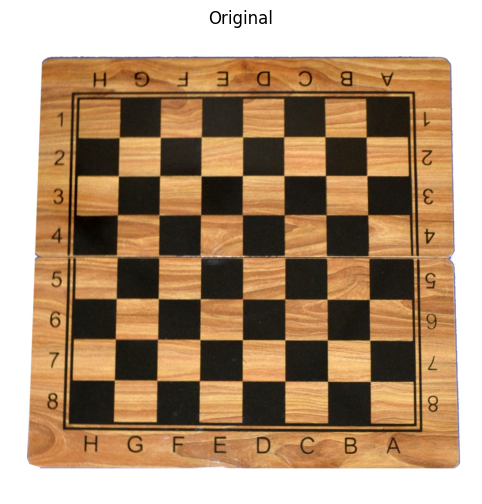

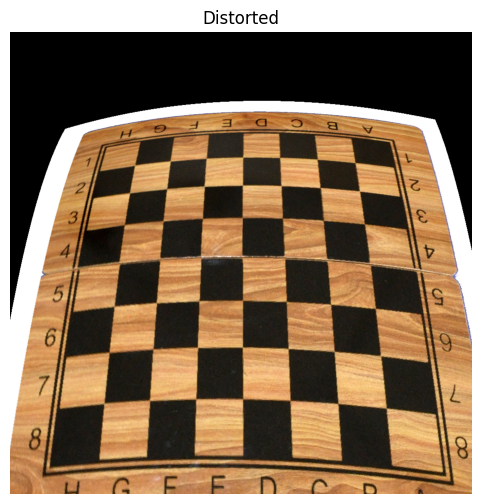

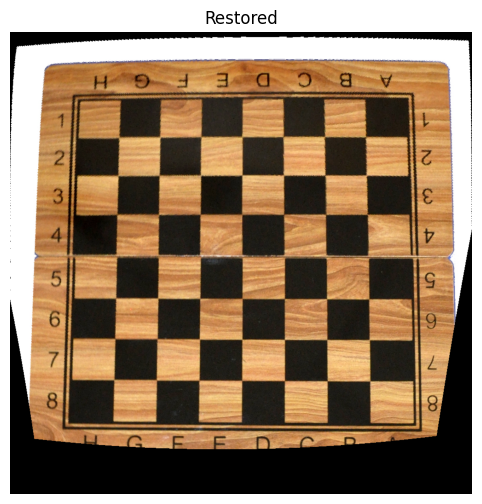

In [54]:
img = cv2.imread("image.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

dist = distort_image(img, p1=2e-5, p2=2e-4)
undist = undistort_image(dist, p1=2e-5, p2=2e-4)

plt.figure(figsize=(8,6))
plt.title("Original")
plt.imshow(img)
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.title("Distorted")
plt.imshow(dist)
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.title("Restored")
plt.imshow(undist)
plt.axis("off")
plt.show()


In [57]:
def distort_image_fast(image, p1, p2):
    h, w = image.shape[:2]
    xc, yc = h / 2, w / 2

    i, j = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

    dx = i - xc
    dy = j - yc
    r2 = dx*dx + dy*dy

    xd = i + (2*p1*dx*dy + p2*(r2 + 2*dx*dx))
    yd = j + (p1*(r2 + 2*dy*dy) + 2*p2*dx*dy)

    map_x = yd.astype(np.float32)
    map_y = xd.astype(np.float32)

    distorted = cv2.remap(image, map_x, map_y, interpolation=cv2.INTER_LINEAR)

    return distorted

In [58]:
def undistort_image_fast(image, p1, p2):
    h, w = image.shape[:2]
    xc, yc = h / 2, w / 2

    i, j = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

    x = i.astype(np.float64)
    y = j.astype(np.float64)

    for _ in range(5):
        dx = x - xc
        dy = y - yc
        r2 = dx*dx + dy*dy

        x1 = x + (2*p1*dx*dy + p2*(r2 + 2*dx*dx))
        y1 = y + (p1*(r2 + 2*dy*dy) + 2*p2*dx*dy)

        x -= 0.5 * (x1 - i)
        y -= 0.5 * (y1 - j)

    map_x = y.astype(np.float32)
    map_y = x.astype(np.float32)

    undistorted = cv2.remap(image, map_x, map_y, interpolation=cv2.INTER_LINEAR)

    return undistorted

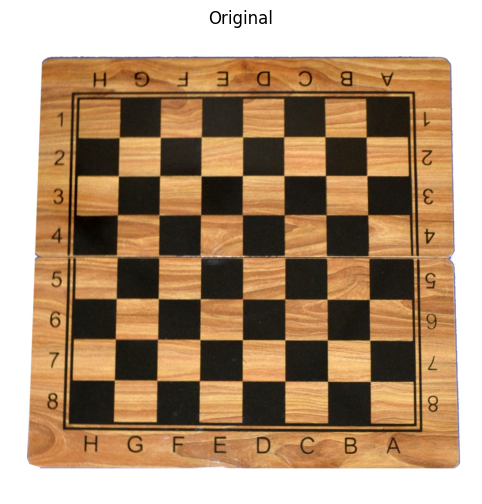

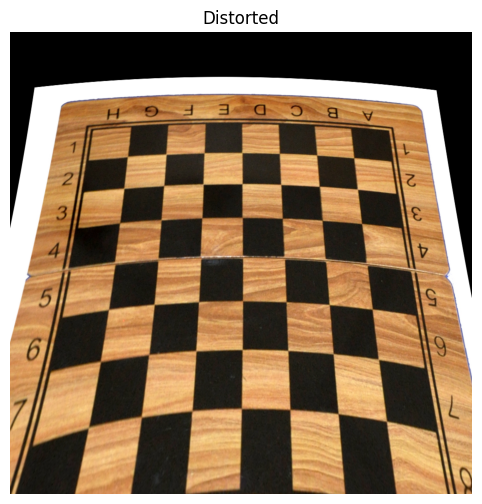

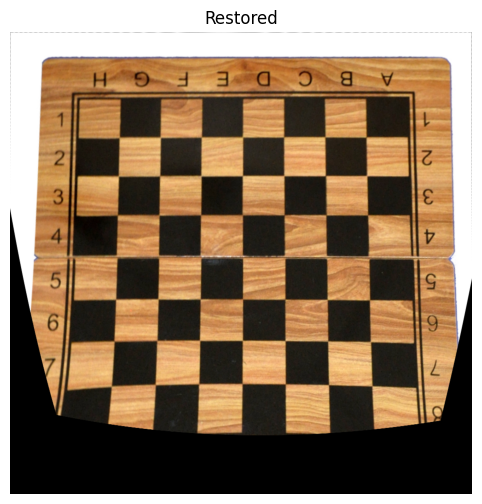

In [59]:
img = cv2.imread("image.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

dist = distort_image_fast(img, p1=2e-5, p2=-2e-4)
undist = undistort_image_fast(dist, p1=2e-5, p2=-2e-4)

plt.figure(figsize=(8,6))
plt.title("Original")
plt.imshow(img)
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.title("Distorted")
plt.imshow(dist)
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.title("Restored")
plt.imshow(undist)
plt.axis("off")
plt.show()

# №2

In [63]:
dt = 0.01  # 100 Hz
t = np.arange(0, 10, dt)

a_true = 0.5
v_true = a_true * t
x_true = 0.5 * a_true * t**2

acc_noise = np.random.normal(0, 0.1, size=len(t))
acc_meas = a_true + acc_noise

gps_interval = int(1 / dt)
gps_meas = x_true[::gps_interval] + np.random.normal(0, 1.0, size=len(x_true[::gps_interval]))

In [64]:
# стан [x, v]
x_est = np.array([[0], [0]])

F = np.array([[1, dt],
              [0, 1]])

B = np.array([[0.5*dt**2],
              [dt]])

H = np.array([[1, 0]])

P = np.eye(2)
Q = np.array([[0.01, 0],
              [0, 0.01]])

R = np.array([[1]])

estimates = []

gps_index = 0

for i in range(len(t)):
    u = acc_meas[i]

    # predict
    x_est = F @ x_est + B * u
    P = F @ P @ F.T + Q

    # update (тільки коли є GPS)
    if i % gps_interval == 0:
        z = gps_meas[gps_index]
        gps_index += 1

        y = z - (H @ x_est)
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x_est = x_est + K @ y
        P = (np.eye(2) - K @ H) @ P

    estimates.append(x_est[0,0])

Mean error: 1.0307072541518785


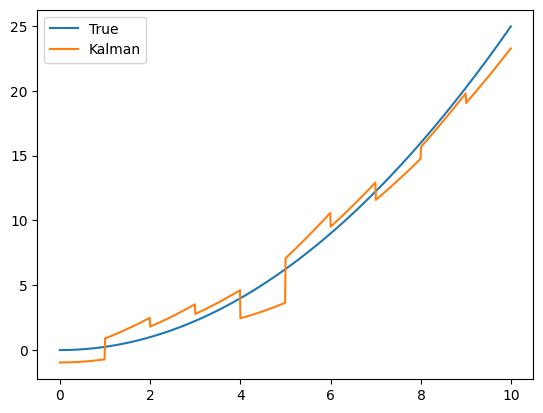

In [65]:
estimates = np.array(estimates)

error = np.mean(np.abs(estimates - x_true))
print("Mean error:", error)

plt.plot(t, x_true, label="True")
plt.plot(t, estimates, label="Kalman")
plt.legend()
plt.show()